## 奇性嵌入格林函数算法：求解二维Poisson方程

## 1. 问题描述(2D Poisson Equations)

考虑二维圆盘上的Poisson方程：

$$
\begin{aligned}
-\Delta u(\bm{x}) = f(\bm{x}), &\ \ \ \ \textnormal{for}\ \bm{x} \in \Omega = \{\bm{x} : \lVert \bm{x} \rVert < 1\}, \\
u(\bm{x}) = 0, &\ \ \ \ \textnormal{for}\ \bm{x}\ \textnormal{on}\ \partial\Omega
\end{aligned} 
$$

其对应的格林函数，对任一固定$\bm{y}\in\Omega$，满足方程：
$$
\begin{aligned}
-\Delta G(\bm{x},\bm{y}) = \delta(\bm{x} -\bm{y}), \ \ \ &\ \textnormal{for}\ \bm{x}\in\Omega,\\
			G(\bm{x},\bm{y}) = 0, \ \ \ &\ \textnormal{for}\ \bm{x}\in\partial\Omega,
\end{aligned}
$$

对于一般二维的正定问题，格林函数$G(\bm{x},\bm{y})$在界面$\Gamma:=\{\bm{x}=\bm{y}\}$附近处有如下奇性的估计：
$$
|G(\bm{x},\bm{y})| \le \ln(\| \bm{x} - \bm{y} \|),
$$
特别的，对于此处的二维Poisson方程，定义$\bm{y}^* := \frac{\bm{y}}{\lVert \bm{y} \rVert^2}$，则格林函数真解可表示为
$$
G(\bm{x},\bm{y}) =  -\frac{1}{2\pi} \ln \left(  \frac{\lVert \bm{x} - \bm{y} \rVert}{\lVert \bm{x} - \bm{y}^* \rVert} \cdot \frac{1}{\lVert \bm{y} \rVert} \right) = - \frac{1}{4\pi}\ln \left( \dfrac{(x_1-y_1)^2+(x_2-y_2)^2}{(x_1y_2-x_2y_1)^2+(x_1y_1+x_2y_2-1)^2} \right).
$$

## 2. 升维嵌入学习方法

通过引入辅助变量$\varphi(\bm{x},\bm{y})=\ln(\| \bm{x} - \bm{y}\|)$，考虑如下形式的解
$$
G(\bm{x},\bm{y}) = \widehat{G}( \bm{x}, \bm{y},  \varphi( \bm{x}, \bm{y} )) 
$$
并将其代入方程推导得出，对任一固定$\bm{y}\in\Omega$，
$$
\begin{aligned}
-\Delta_{\bm{x}}\widehat{G}(\bm{x},\bm{y},\varphi(\bm{x},\bm{y})) - 2 \nabla_{\bm{x}} \big( \partial_z\widehat{G}(\bm{x},\bm{y},\varphi(\bm{x},\bm{y})) \big) \cdot \dfrac{\bm{x}-\bm{y}}{\lVert \bm{x} - \bm{y} \rVert ^2}  - \dfrac{\partial_{zz}\widehat{G}(\bm{x},\bm{y},\varphi(\bm{x},\bm{y}))}{\lVert \bm{x} - \bm{y} \rVert ^2} = 0, \ \ \ &\ \textnormal{for}\ \bm{x}\in\Omega\setminus\Gamma, \\
\displaystyle -\int_{\partial B_\epsilon (\bm{y})} \bigg(\nabla_{\bm{x}}G(\bm{x},\bm{y},\varphi(\bm{x},\bm{y})) \cdot \dfrac{\bm{x}-\bm{y}}{\lVert \bm{x} - \bm{y} \rVert} + \dfrac{\partial_z\widehat{G}(\bm{x},\bm{y},\varphi(\bm{x},\bm{y}))}{\lVert \bm{x} - \bm{y} \rVert}\bigg) d S(\bm{x}) = 1, \ \ \ &\ \textnormal{for} \ \bm{x}\in\Gamma,\\
G(\bm{x},\bm{y},\varphi(\bm{x},\bm{y})) = 0, \ \ \ &\ \textnormal{for}\ \bm{x}\in\partial\Omega,
\end{aligned}
$$

### 函数逼近
由于辅助变量的引入导致函数自变量维数的升高，因此需采用无惧“维数灾难”的函数逼近工具，即人工神经网络

在此，我们使用一个全连接网络（fully-connected neural network）来参数化未知函数，其中神经网络的待定参数用 
$\theta$表示，即

$$
\widehat{G}(\bm{x},\bm{y},\varphi(\bm{x},\bm{y})) \approx \widehat{G}_{NN}(\bm{x},\bm{y},\varphi(\bm{x},\bm{y})).
$$

损失函数

通过方程的残量来定义格林函数在光滑、奇性、边界处的损失函数
$$
\displaystyle  L_{\textnormal{Reglr}} (\theta) = \frac{1}{M} \sum_{m=1}^M \bigg( \frac{1}{N_{\textnormal{R}}} \sum_{n=1}^{N_{\textnormal{R}}} 
			\bigg| \Big( \Delta_{\bm{x}}+ 2 \nabla \varphi( \bm{x}_n^{\Omega}, \bm{y}_m ) \cdot \nabla_{\bm{x}} \, \partial_z + \|\nabla \varphi( \bm{x}_n^{\Omega}, \bm{y}_m ) \|^2 \partial_{zz} \Big)\widehat{G}( \bm{x}_n^{\Omega}, \bm{y}_m, \varphi( \bm{x}_n^{\Omega}, \bm{y}_m ) ;\theta) \bigg|^2 \bigg), \\[0.3cm]
			\displaystyle L_{\textnormal{Snglr}}^{d\geq 2} (\theta) = \frac{1}{M} \sum_{m=1}^M \bigg( 1 + \frac{2\pi \epsilon}{N_{\textnormal{S}}} \sum_{n=1}^{N_{\textnormal{S}}}  \big( \nabla_{\bm{x}} + \nabla \varphi( \bm{x}_n^{\Gamma}, \bm{y}_m ) \partial_z \big) \widehat{G}( \bm{x}_n^{\Gamma}, \bm{y}_m, \varphi( \bm{x}_n^{\Gamma}, \bm{y}_m ) ;\theta) \cdot \frac{\bm{x}_n^\Gamma - \bm{y}_m}{ \lVert \bm{x}_n^\Gamma - \bm{y}_m \rVert}  \bigg)^2, \\
			\displaystyle L_{\textnormal{Bndry}} (\theta) =  \frac{1}{M} \sum_{m=1}^M \bigg( \frac{1}{N_{\textnormal{B}}} \sum_{n=1}^{N_{\textnormal{B}}} \big|  \widehat{G}( \bm{x}_n^{\partial \Omega}, \bm{y}_m, \varphi( \bm{x}_n^{\partial\Omega}, \bm{y}_m ) ;\theta) \big|^2 \bigg),
$$

接下来的程序将测试算法在点源$\bm{y}=(0,0)$上解$G(\bm{x},0,0)$的精度。

## 3.编程求解

### 3-1. 准备工作 - 调用函数库

In [2]:
import torch
import torch.nn as nn
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import time
import datetime
import argparse 

from torch import optim, autograd
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt

# matlab to tensor and vice versa
from scipy.io import loadmat
import numpy as np
import scipy.io as io

# load data from two datasets within the same loop
from itertools import cycle

print("pytorch version", torch.__version__, "\n")
torch.set_default_dtype(torch.float64)

pytorch version 1.11.0+cpu 



### 3-1. 准备工作 - 全连接神经网络

In [3]:
class FcBlock(nn.Module):
    """ 
        dim_in  -- dimension of each block's input data
        width   -- number of nodes in each block's hidden layer
        dim_out -- dimension of each block's output data (not the dimension of final output)  
    """
    
    def __init__(self, dim_in, width, dim_out):
        super(FcBlock, self).__init__()

        # set parameters
        self.dim_in = dim_in
        self.width = width
        self.dim_out = dim_out

        # create linear layers
        self.Linear1 = nn.Linear(dim_in, width)
        self.Linear2 = nn.Linear(width, dim_out)  
        # choose activation function = Tanh
        self.activation = nn.Tanh()      

    def forward(self, x):
        
        return self.activation(self.Linear2(self.activation(self.Linear1(x))))


class FcNet(nn.Module):
    """ 
        dim_in  -- dimension of each block's input data
        width   -- number of nodes in each block's hidden layer
        dim_out -- dimension of final output data   
    """

    def __init__(self, dim_in, width, dim_out, depth):
        super(FcNet, self).__init__()

        # set parameters
        self.dim_in = dim_in
        self.width = width
        self.dim_out = dim_out
        self.depth = depth

        # creat a list for holding all blocks/layers
        self.stack = nn.ModuleList()
                
        # input layer       
        self.stack.append(nn.Linear(dim_in, width))
        # add hidden blocks
        for i in range(depth):
            self.stack.append(FcBlock(width, width, width))        
        # output layer
        self.stack.append(nn.Linear(width, dim_out))  
        
    def forward(self, x):
        
        for layer in self.stack:
            x = layer(x)

        return x

    def Xavier_initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    m.bias.data.zero_()  

## 3-1. 准备工作 - 训练和测试数据集

c:\Users\LittleVivien\anaconda3\envs\PyTorch\lib\site-packages\torch\functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


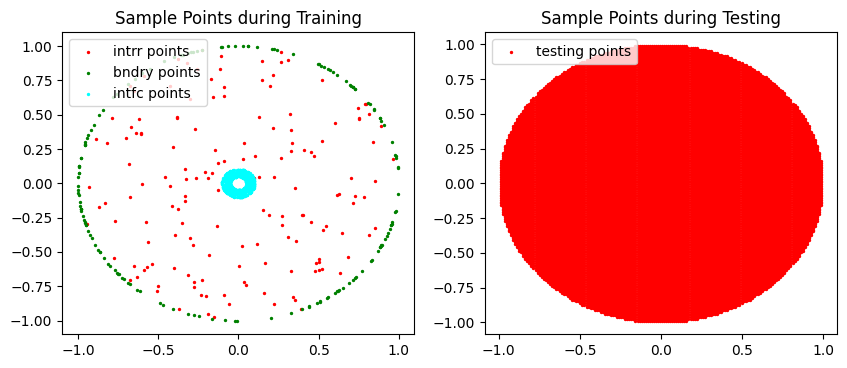

In [4]:
# fixed y
y = 0.0

# number of collocation points for each part
traindata_size_intrr_x = 160
traindata_size_bndry_x = 160 
traindata_size_intfc_x = 160
num_snglr_circles = 4

# generate testing points over the entire domain
x1 = torch.linspace(-1, 1, steps=traindata_size_intrr_x)
x2 = torch.linspace(-1, 1, steps=traindata_size_intrr_x)
X1, X2 = torch.meshgrid(x1, x2)
TestPts_x = torch.squeeze(torch.stack([X1.reshape(1,-1), X2.reshape(1,-1)], dim=-1))
TestPts_y = torch.zeros_like(TestPts_x)
testdata = torch.cat((TestPts_x, TestPts_y),1)

def SmpPts_Interior_Plate2D(traindata_size_intrr_x):
    
    r_x = torch.sqrt(torch.rand(traindata_size_intrr_x, 1))
    theta_x = 2 * np.pi * torch.rand(traindata_size_intrr_x, 1)

    IntrrPts_x = torch.cat((r_x * torch.cos(theta_x), r_x * torch.sin(theta_x)), dim=1)
    IntrrPts_y = torch.zeros_like(IntrrPts_x) 

    return torch.cat((IntrrPts_x,IntrrPts_y), dim=1)

def SmpPts_Boundary_Plate2D(traindata_size_bndry_x): 

    theta_x = 2 * np.pi * torch.rand(traindata_size_bndry_x, 1)
    BndryPts_x = torch.cat((torch.cos(theta_x), torch.sin(theta_x)), dim=1)
    IntrrPts_y = torch.zeros_like(BndryPts_x)
    
    return torch.cat((BndryPts_x, IntrrPts_y), dim=1)

def SmpPts_Intfc_Plate2D(traindata_size_intfc_x, num_circles=4):
    
    max_varepsilon = 0.1
    varepsilon = (max_varepsilon * 0.8 ** (torch.linspace(1,num_circles,num_circles).unsqueeze(1)-1)).unsqueeze(1)
    circle_r_x = varepsilon.repeat(1, traindata_size_intfc_x, 1)
    theta_x = 2 * np.pi * torch.rand(num_circles, traindata_size_intfc_x, 1)
    
    IntrrPts_y = torch.zeros_like(torch.cat((circle_r_x, theta_x) ,dim=2)) 
    
    return torch.cat((circle_r_x * torch.cos(theta_x), circle_r_x * torch.sin(theta_x), IntrrPts_y), dim=2)

smppts_intrr = SmpPts_Interior_Plate2D(traindata_size_intrr_x)
smppts_bndry = SmpPts_Boundary_Plate2D(traindata_size_bndry_x)
smppts_intfc = SmpPts_Intfc_Plate2D(traindata_size_intfc_x)

fig = plt.figure(figsize=(10, 4), dpi= 100)
plt.subplot(1, 2, 1)
plt.scatter(smppts_intrr[:,0], smppts_intrr[:,1], c = 'red', label = 'intrr points', s=2)
plt.scatter(smppts_bndry[:,0], smppts_bndry[:,1], c = 'green', label = 'bndry points', s=2)
plt.scatter(smppts_intfc[:,:,0].reshape(-1,1), smppts_intfc[:,:,1].reshape(-1,1), c = 'cyan', label = 'intfc points', s=2)
plt.title('Sample Points during Training')
plt.legend(loc = 'upper left')

plt.subplot(1, 2, 2)
plt.scatter(X1[(X1 ** 2 + X2 ** 2)<= 1], X2[(X1 ** 2 + X2 ** 2)<= 1], c = 'red', label = 'testing points', s=2)
plt.title('Sample Points during Testing')
plt.legend(loc = 'upper left')
plt.show()

## 3-1. 准备工作 - 升维函数在样本点处的值

In [5]:
# append the value of auxiliary variable for each input data point
smppts_intrr = torch.cat([smppts_intrr, torch.log(torch.norm(smppts_intrr[:,0:2]-smppts_intrr[:,2:4], dim=1, keepdim=True))], dim=1)
smppts_bndry = torch.cat([smppts_bndry, torch.log(torch.norm(smppts_bndry[:,0:2]-smppts_bndry[:,2:4], dim=1, keepdim=True))], dim=1)
smppts_intfc = torch.cat([smppts_intfc, torch.log(torch.norm(smppts_intfc[:,:,0:2]-smppts_intfc[:,:,2:4], dim=2, keepdim=True))], dim=2)
smppts_test = torch.cat([testdata, torch.log(torch.norm(testdata[:,0:2]-testdata[:,2:4], dim=1, keepdim=True))], dim=1)

# exact solution 
def Green_Exact_Plate2D(x, y):
    r = torch.norm( x - y, dim=1) 
    r_x = torch.norm(x, dim=1, keepdim=True)
    x_symtry = x / r_x ** 2
    r_symtry = torch.norm( y - x_symtry, dim=1)
    rho = torch.norm(x, dim=1)
    return - torch.log(r / (r_symtry * rho)) / ( 2 * np.pi)

# load train data in mini-batches
batch_num = 4
batchsize_intrr = traindata_size_intrr_x // batch_num
batchsize_bndry = traindata_size_bndry_x // batch_num
batchsize_intfc = num_snglr_circles // batch_num

dataset_intrr = TensorDataset(smppts_intrr)
dataset_bndry = TensorDataset(smppts_bndry)
dataset_intfc = TensorDataset(smppts_intfc)
dataloader_intrr= DataLoader(dataset_intrr, batch_size=batchsize_intrr, shuffle=True)
dataloader_bndry= DataLoader(dataset_bndry, batch_size=batchsize_bndry, shuffle=True)
dataloader_intfc= DataLoader(dataset_intfc, batch_size=batchsize_intfc, shuffle=True)

## 3-2. 网络训练

Done in 0:00:49.657385 !


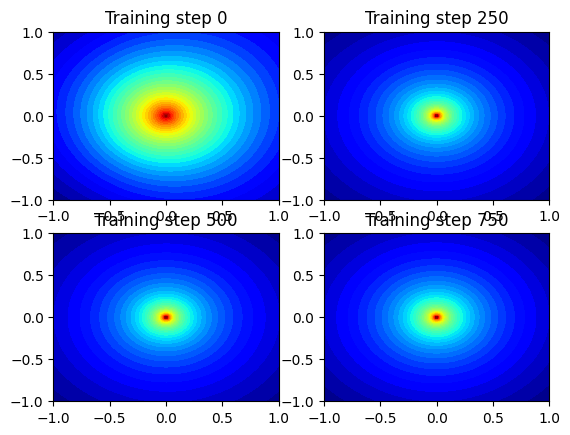

In [6]:
# penalty coefficient
beta_bndry = beta_intfc = 400
# for decay of learning rate
milestones = [500,650]

# create model
model = FcNet(5, 40, 1, 2)
model.Xavier_initi()

# create optimizer and learning rate schedular 
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.01, amsgrad=False)
schedular = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones, gamma=0.1)

since = time.time()

for i in range(751):
    
    for _, ( (data_intrr,), (data_bndry,), (data_intfc,) ) in \
        enumerate(zip(dataloader_intrr, cycle(dataloader_bndry), cycle(dataloader_intfc)) ):
        
        # enable computing gradients through autograd
        data_intrr.requires_grad = True
        data_bndry.requires_grad = True
        data_intfc.requires_grad = True

        data_intfc = torch.squeeze(data_intfc)
        
        # forward pass 
        G_NN_intrr = model(data_intrr)
        G_NN_bndry = model(data_bndry)
        G_NN_intfc = model(data_intfc)
        
        # zero parameter gradients and then compute NN prediction of the derivatives 
        model.zero_grad()
        grad_NN_intrr = torch.autograd.grad(outputs=G_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(G_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0]
        Gx1_NN_intrr, Gx2_NN_intrr, Gz_NN_intrr = grad_NN_intrr[:,[0]], grad_NN_intrr[:,[1]], grad_NN_intrr[:,[-1]]
        
        Gx1x1_NN_intrr = torch.autograd.grad(outputs=Gx1_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gx1_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[0]]
        Gx2x2_NN_intrr = torch.autograd.grad(outputs=Gx2_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gx2_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[1]]
        Gx1z_NN_intrr = torch.autograd.grad(outputs=Gx1_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gx1_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[-1]]
        Gx2z_NN_intrr = torch.autograd.grad(outputs=Gx2_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gx2_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[-1]]
        Gzz_NN_intrr = torch.autograd.grad(outputs=Gz_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gz_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[-1]]
        
        dist_xy_intrr = torch.norm(data_intrr[:,0:2] - data_intrr[:,2:4], dim=1, keepdim=True)
        normVec_intrr = (data_intrr[:,0:2] - data_intrr[:,2:4]) / dist_xy_intrr ** 2
        
        Operator_Lg_intrr = - ( Gx1x1_NN_intrr + Gx2x2_NN_intrr + 2 * Gx1z_NN_intrr * normVec_intrr[:,[0]]
                      + 2 * Gx2z_NN_intrr * normVec_intrr[:,[1]] + Gzz_NN_intrr / dist_xy_intrr ** 2)
        
        grad_NN_intfc = torch.autograd.grad(outputs=G_NN_intfc, inputs=data_intfc, grad_outputs=torch.ones_like(G_NN_intfc), retain_graph=True, create_graph=True, only_inputs=True)[0]
        Gx1_NN_intfc, Gx2_NN_intfc, Gz_NN_intfc = grad_NN_intfc[:,[0]], grad_NN_intfc[:,[1]], grad_NN_intfc[:,[-1]]

        Int_Snglr = - 2 * np.pi * (Gx1_NN_intfc * data_intfc[:,[0]] + Gx2_NN_intfc * data_intfc[:,[1]] + Gz_NN_intfc)
        
        # construct mini-batch loss function and then perform backward pass
        loss_intrr = torch.mean( torch.pow( torch.squeeze( Operator_Lg_intrr ), 2 ) )
        loss_intfc = torch.mean( torch.pow( torch.squeeze( Int_Snglr - 1 ), 2 ) )
        loss_bndry = torch.mean( torch.pow( torch.squeeze( G_NN_bndry ), 2 ) ) 
                                       
        loss_minibatch = loss_intrr + beta_bndry * loss_bndry + beta_intfc * loss_intfc

        # zero parameter gradients
        optimizer.zero_grad()
        # backpropagation
        loss_minibatch.backward()
        # parameter update
        optimizer.step()

        
        # plot the result as training progresses
        list_of_plots = []
        plt.rcdefaults()

        if i % 250 == 0: 
            ax = plt.subplot(2, 2, i // 250 + 1)
        
            G_test = model(smppts_test).detach()
            G_test = G_test.reshape(traindata_size_intrr_x, traindata_size_intrr_x)    
            G_test[G_test > 1e3] = 1e3
            ax.contourf(X1, X2, G_test, 40, cmap = 'jet')        
            ax.set_title(f"Training step {i}")
        
            list_of_plots.append(ax)
    
time_elapsed = time.time() - since
print('Done in {}'.format(str(datetime.timedelta(seconds=time_elapsed))), '!')

## 3-3. 展示计算结果

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


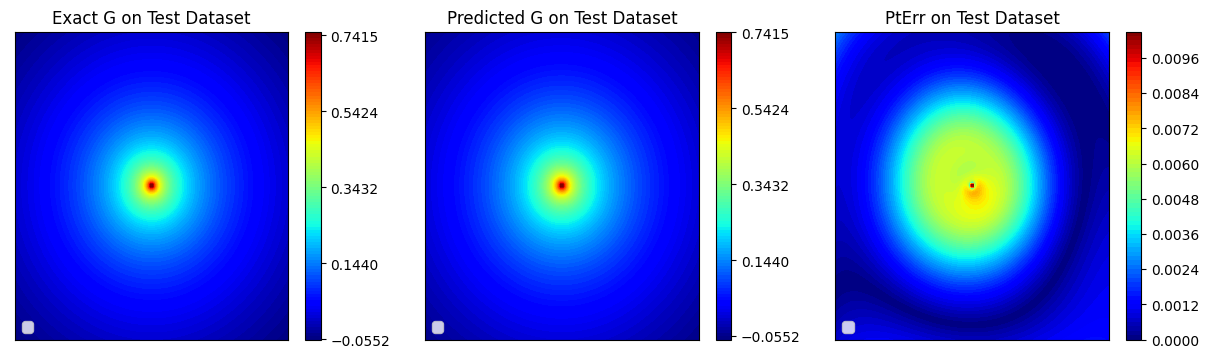

In [7]:
# plot the solution at y = 0.3
G_exact = Green_Exact_Plate2D(smppts_test[:,0:2], smppts_test[:,2:4])
G_pred = model(smppts_test).detach()
G_exact[torch.isnan(G_exact)] = 1e3
G_exact[G_exact>1e3], G_pred[G_pred>1e3] = 1e3, 1e3
G_exact = G_exact.reshape(traindata_size_intrr_x, traindata_size_intrr_x)
G_pred = G_pred.reshape(traindata_size_intrr_x, traindata_size_intrr_x)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.contourf(X1, X2, G_exact, 100, cmap = 'jet')
bounds = torch.linspace(G_exact.min(), G_pred.max(), 5)
plt.colorbar(ticks=bounds)
plt.xticks([])
plt.yticks([])
plt.title('Exact G on Test Dataset')
plt.legend(loc = 'lower left')

plt.subplot(1, 3, 2)
plt.contourf(X1, X2, G_pred, 100, cmap = 'jet')
plt.colorbar(ticks=bounds)
plt.xticks([])
plt.yticks([])
plt.title('Predicted G on Test Dataset')
plt.legend(loc = 'lower left')

plt.subplot(1, 3, 3)
plt.contourf(X1, X2, torch.abs(G_exact-G_pred), 100, cmap = 'jet')
plt.colorbar()
plt.xticks([])
plt.yticks([])
plt.title('PtErr on Test Dataset')
plt.legend(loc = 'lower left')